In [38]:
import os.path

import pyranges

gencode = pyranges.read_gtf("../../data/gencode.v40.basic.annotation.gtf")

genes_from_gencode = (
    gencode
    [(gencode['Feature'] == 'gene')]
    [['Chromosome', 'Start', 'End', 'gene_id']]
)

genes_from_gencode['gene_id'] = genes_from_gencode['gene_id'].str.split('.').str[0]

genes_from_gencode

,Chromosome,Start,End,gene_id
0,chr1,11868,14409,ENSG00000223972
12,chr1,14403,29570,ENSG00000227232
25,chr1,17368,17436,ENSG00000278267
28,chr1,29553,31109,ENSG00000243485
36,chr1,30365,30503,ENSG00000284332
...,...,...,...,...
1926897,chrM,14148,14673,ENSG00000198695
1926902,chrM,14673,14742,ENSG00000210194
1926905,chrM,14746,15887,ENSG00000198727
1926910,chrM,15887,15953,ENSG00000210195


In [39]:
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

with open("../../data/rnaseq/gm12878_read_count.txt", "r") as f:
    f.readline()
    gm12878_counts_df = pd.read_csv(f, index_col=0, sep="\t")


with open("../../data/rnaseq/h1esc_read_count.txt", "r") as f:
    f.readline()
    h1esc_counts_df = pd.read_csv(f, index_col=0, sep="\t")

with open("../../data/rnaseq/hffc6_read_count.txt", "r") as f:
    f.readline()
    hffc6_counts_df = pd.read_csv(f, index_col=0, sep="\t")

gm12878_counts_df = gm12878_counts_df[['ENCFF800HIP.filtered.bam', 'ENCFF991KKX.filtered.bam']].T
h1esc_counts_df = h1esc_counts_df[['ENCFF675NTU.filtered.bam', 'ENCFF379NOY.filtered.bam']].T
hffc6_counts_df = hffc6_counts_df[['ENCFF307KUI.filtered.bam', 'ENCFF294BSI.filtered.bam', 'ENCFF937TEI.filtered.bam']].T

def compute_deseq_stats_for_2_celllines(cellline1_counts_df, cellline2_counts_df, cellline1_name="CellLine1", cellline2_name="CellLine2"):
    cl1_vs_cl2_counts_df = pd.concat(
        [cellline1_counts_df, cellline2_counts_df]
    )

    cl1_vs_cl2_metadata_df = pd.DataFrame(
        {
            "condition": [cellline1_name] * cellline1_counts_df.shape[0] + [cellline2_name] * cellline2_counts_df.shape[0]
        },
        index=cl1_vs_cl2_counts_df.index,
    )

    inference = DefaultInference(n_cpus=8)
    dds = DeseqDataSet(
        counts=cl1_vs_cl2_counts_df,
        metadata=cl1_vs_cl2_metadata_df,
        design="~condition",
        refit_cooks=True,
        inference=inference,
    )

    dds.deseq2()
    stats = DeseqStats(dds, contrast=["condition", cellline2_name, cellline1_name])
    stats.summary()

    stats.lfc_shrink(coeff=f"condition[T.{cellline2_name}]")
    # stats.lfc_shrink(coeff=stats.LFC.columns[1])

    results_df = stats.results_df.dropna()
    results_df['symbol'] = results_df.index
    return results_df

if os.path.exists("../../data/deseq/gm12878_vs_h1esc_results.parquet"):
    gm12878_vs_h1esc_results_df = pd.read_parquet("../../data/deseq/gm12878_vs_h1esc_results.parquet")
else:
    gm12878_vs_h1esc_results_df = compute_deseq_stats_for_2_celllines(
        gm12878_counts_df,
        h1esc_counts_df,
        cellline1_name="GM12878",
        cellline2_name="H1ESC"
    )
    gm12878_vs_h1esc_results_df.to_parquet("../../data/deseq/gm12878_vs_h1esc_results.parquet")

if os.path.exists("../../data/deseq/h1esc_vs_hffc6_results.parquet"):
    h1esc_vs_hffc6_results_df = pd.read_parquet("../../data/deseq/h1esc_vs_hffc6_results.parquet")
else:
    h1esc_vs_hffc6_results_df = compute_deseq_stats_for_2_celllines(
        h1esc_counts_df,
        hffc6_counts_df,
        cellline1_name="H1ESC",
        cellline2_name="HFFC6"
    )
    h1esc_vs_hffc6_results_df.to_parquet("../../data/deseq/h1esc_vs_hffc6_results.parquet")

if os.path.exists("../../data/deseq/gm12878_vs_hffc6_results.parquet"):
    gm12878_vs_hffc6_results_df = pd.read_parquet("../../data/deseq/gm12878_vs_hffc6_results.parquet")
else:
    gm12878_vs_hffc6_results_df = compute_deseq_stats_for_2_celllines(
        gm12878_counts_df,
        hffc6_counts_df,
        cellline1_name="GM12878",
        cellline2_name="HFFC6",
    )
    gm12878_vs_hffc6_results_df.to_parquet("../../data/deseq/gm12878_vs_hffc6_results.parquet")

In [40]:
hffc6_vs_gm12878_results_df = gm12878_vs_hffc6_results_df.copy()
hffc6_vs_gm12878_results_df['log2FoldChange'] = -hffc6_vs_gm12878_results_df['log2FoldChange']
hffc6_vs_gm12878_results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,symbol
Geneid,,,,,,,
ENSG00000227232.5,4.876008,-4.555738,2.193361,2.181255,0.029165,0.070721,ENSG00000227232.5
ENSG00000278267.1,1.138906,0.250018,1.193712,-0.610732,0.541377,0.771679,ENSG00000278267.1
ENSG00000238009.6,1.072304,0.503159,1.251394,-1.183214,0.236725,0.420047,ENSG00000238009.6
ENSG00000233750.3,0.353368,0.166119,1.111811,-0.463364,0.643103,0.836999,ENSG00000233750.3
ENSG00000268903.1,8.401750,6.974442,2.777177,-3.118622,0.001817,0.005614,ENSG00000268903.1
...,...,...,...,...,...,...,...
ENSG00000198695.2,1520.630326,0.225613,0.157064,-1.464713,0.142999,0.279301,ENSG00000198695.2
ENSG00000210194.1,16.391290,1.314085,0.595190,-2.590932,0.009572,0.025888,ENSG00000210194.1
ENSG00000198727.2,30956.220844,0.797251,0.190630,-4.278273,0.000019,0.000076,ENSG00000198727.2


In [41]:
gene_to_closest_avg_enhancer_all = pd.read_parquet("../../data/whole_chromosomes/genes_all_cell_lines_v3.snappy.parquet")
gm12878_gene_to_closest_avg_enhancer_all = gene_to_closest_avg_enhancer_all[gene_to_closest_avg_enhancer_all['cell_line'] == 'GM12878'].set_index('gene_id').drop(columns=['cell_line'])
h1esc_gene_to_closest_avg_enhancer_all = gene_to_closest_avg_enhancer_all[gene_to_closest_avg_enhancer_all['cell_line'] == 'H1ESC'].set_index('gene_id').drop(columns=['cell_line'])
hffc6_gene_to_closest_avg_enhancer_all = gene_to_closest_avg_enhancer_all[gene_to_closest_avg_enhancer_all['cell_line'] == 'HFFC6'].set_index('gene_id').drop(columns=['cell_line'])

def add_chromosome_and_quartiles(df, name):
    df = df.merge(genes_from_gencode[['gene_id', 'Chromosome']], left_index=True, right_on='gene_id', how='left').set_index('gene_id')

    def compute_quartiles(group):
        q1 = group['min_dist'].quantile(0.33)
        q3 = group['min_dist'].quantile(0.67)
        def label_quartile(x):
            if x <= q1:
                return 'small'
            elif x <= q3:
                return 'mid'
            else:
                return 'large'
        group['quartile_cat'] = group['min_dist'].apply(label_quartile)
        return group

    df = df.groupby('Chromosome', group_keys=False).apply(compute_quartiles, include_groups=False)
    return df

gm12878_gene_to_closest_avg_enhancer_all = add_chromosome_and_quartiles(gm12878_gene_to_closest_avg_enhancer_all, 'gm12878')
hffc6_gene_to_closest_avg_enhancer_all = add_chromosome_and_quartiles(hffc6_gene_to_closest_avg_enhancer_all, 'hffc6')
h1esc_gene_to_closest_avg_enhancer_all = add_chromosome_and_quartiles(h1esc_gene_to_closest_avg_enhancer_all, 'h1esc')

In [42]:
gm12878_gene_to_closest_avg_enhancer_all

,project_id,avg_dist,min_dist,max_dist,quartile_cat
gene_id,,,,,
ENSG00000094914,whole_all_vs_all_gm12878_fix,85.483211,1.851314,203.034027,mid
ENSG00000258012,whole_all_vs_all_gm12878_fix,140.225051,8.961069,251.205017,mid
ENSG00000257596,whole_all_vs_all_gm12878_fix,85.879081,4.000490,203.226471,mid
ENSG00000118971,whole_all_vs_all_gm12878_fix,89.018759,3.265652,197.030502,mid
ENSG00000111671,whole_all_vs_all_gm12878_fix,88.655649,1.553416,196.678360,small
...,...,...,...,...,...
ENSG00000197696,whole_all_vs_all_gm12878_fix,77.057342,1.317909,260.666382,mid
ENSG00000260608,whole_all_vs_all_gm12878_fix,79.975464,0.523023,277.504913,small
ENSG00000259468,whole_all_vs_all_gm12878_fix,114.043947,5.036004,174.152191,large


In [43]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np
import joypy
from matplotlib import cm

def plot_distance_vs_expression_correlation(
    cell1_distances_df,
    cell2_distances_df,
    deseq_results_df,
    cell1_name,
    cell2_name,
    figsize=(20, 20),
    plot_path=None,
    color_map=cm.viridis,
    font_size=24,
    log2fc_threshold=2,
    padj_threshold=0.05
):
    deseq_results_df = deseq_results_df.copy()

    deseq_results_df.index = deseq_results_df.index.str.split('.').str[0]

    deseq_results_df = deseq_results_df[
        (deseq_results_df["padj"] < padj_threshold)
        & (deseq_results_df["log2FoldChange"].abs() >= log2fc_threshold)
    ]

    cell1_distances_df = cell1_distances_df.copy()
    cell1_distances_df['norm_min_dist'] = (
        (cell1_distances_df['min_dist'] - cell1_distances_df['min_dist'].min()) / (cell1_distances_df['min_dist'].max() - cell1_distances_df['min_dist'].min())
    )

    cell2_distances_df = cell2_distances_df.copy()
    cell2_distances_df['norm_min_dist'] = (
        (cell2_distances_df['min_dist'] - cell2_distances_df['min_dist'].min()) / (cell2_distances_df['min_dist'].max() - cell2_distances_df['min_dist'].min())
    )

    combined_df = cell1_distances_df.merge(
        cell2_distances_df,
        left_index=True,
        right_index=True,
        how="inner",
        suffixes=(f"_{cell1_name}", f"_{cell2_name}")
    )

    combined_df["log_dist_ratio"] = np.log2(combined_df[f"min_dist_{cell2_name}"] / combined_df[f"min_dist_{cell1_name}"])
    combined_df["dist_diff"] = combined_df[f"min_dist_{cell2_name}"] - combined_df[f"min_dist_{cell1_name}"]

    combined_df["norm_dist_diff"] = combined_df[f"norm_min_dist_{cell2_name}"] - combined_df[f"norm_min_dist_{cell1_name}"]
    combined_df["log_norm_dist_ratio"] = np.log2(combined_df[f"norm_min_dist_{cell2_name}"] / combined_df[f"norm_min_dist_{cell1_name}"])

    # Define link change categories
    def get_link_change(row):
        if row[f"has_link_{cell1_name}"] and not row[f"has_link_{cell2_name}"]:
            return f"Only {cell1_name}"
        elif not row[f"has_link_{cell1_name}"] and row[f"has_link_{cell2_name}"]:
            return f"Only {cell2_name}"
        elif row[f"has_link_{cell1_name}"] and row[f"has_link_{cell2_name}"]:
            return "Both"
        else:
            return "Neither"

    # combined_df["link_status"] = combined_df.apply(get_link_change, axis=1)

    def get_quartile_change(row):
        q1 = row[f"quartile_cat_{cell1_name}"]
        q2 = row[f"quartile_cat_{cell2_name}"]

        if q1 == q2:
            return "No change"

        categories = ["small", "mid", "large"]
        idx1 = categories.index(q1)
        idx2 = categories.index(q2)

        if idx1 > idx2:
            return f"Decreased ({q1} to {q2})"
        else:
            return f"Increased ({q1} to {q2})"

    combined_df["quartile_change"] = combined_df.apply(get_quartile_change, axis=1)

    merged_df = combined_df.merge(
        deseq_results_df[["log2FoldChange", "padj"]],
        left_index=True,
        right_index=True,
        how="inner"
    )

    merged_df_for_correlation = merged_df.copy()
    merged_df_for_correlation = merged_df_for_correlation[
        ~merged_df_for_correlation["quartile_change"].isin([
            "No change",
            "Increased (small to mid)",
            "Increased (mid to large)",
            "Decreased (large to mid)",
            "Decreased (mid to small)",
        ])
    ]

    merged_df_for_plotting = merged_df.copy()
    merged_df_for_plotting = merged_df_for_plotting[
        ~merged_df_for_plotting["quartile_change"].isin([
            "Increased (small to mid)",
            "Increased (mid to large)",
            "Decreased (large to mid)",
            "Decreased (mid to small)",
        ])
    ]

    pearson_r, pearson_p = pearsonr(merged_df_for_correlation["log_norm_dist_ratio"], merged_df_for_correlation["log2FoldChange"], alternative='two-sided')
    spearman_r, spearman_p = spearmanr(merged_df_for_correlation["norm_dist_diff"], merged_df_for_correlation["log2FoldChange"], alternative='two-sided')

    quartile_order = [
        "Increased (small to large)",
        # "Increased (mid to large)",
        # "Increased (small to mid)",
        "No change",
        "Decreased (large to small)",
        # "Decreased (mid to small)",
        # "Decreased (large to mid)"
    ]

    available_categories = merged_df_for_plotting["quartile_change"].unique()
    plot_order = [cat for cat in quartile_order if cat in available_categories]

    plot_data = {}
    for category in plot_order:
        subset = merged_df_for_plotting[merged_df_for_plotting["quartile_change"] == category]
        if len(subset) >= 3:
            plot_data[category] = subset["log2FoldChange"]

    # Create figure
    fig, axes = joypy.joyplot(
        plot_data,
        figsize=figsize,
        colormap=color_map,
        overlap=0.7,
        linewidth=1,
        alpha=0.8,
        grid="y",
        legend=False,
        title=f"Expression Change by Distance Change for {cell1_name} vs {cell2_name}\n" +
              # f"Pearson r: {pearson_r:.3f} (p: {pearson_p:.2e}) | " +
              f"Spearman r: {spearman_r:.3f} (p: {spearman_p:.2e})",
        range_style='own',

    )

    print(f'Pearson r: {pearson_r:.3f}, p-value: {pearson_p:.2e}')
    print(f'Spearman r: {spearman_r:.3f}, p-value: {spearman_p:.2e}')

    plt.xlabel("Log2 Fold Change", fontsize=font_size, fontweight='bold')

    for ax in axes[:-1]:  # Skip the last ax which is just for the x-axis
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

    for ax in axes[:-1]:  # Skip the last ax which is just for the x-axis
        ax.axvline(x=-log2fc_threshold, color='gray', linestyle='--', alpha=0.7, linewidth=1)
        ax.axvline(x=log2fc_threshold, color='gray', linestyle='--', alpha=0.7, linewidth=1)

    title = axes[-1].get_title()
    axes[-1].set_title(title, fontsize=font_size, fontweight='bold')
    for ax in axes:
        label = ax.get_yticklabels()
        ax.set_yticklabels(label, fontsize=font_size, fontweight='bold')
    # for ax, category in zip(axes[:-1], plot_order):
    #     if category in plot_data:
    #         mean_value = plot_data[category].mean()
    #         ax.axvline(x=mean_value, color='red', linestyle='-', alpha=0.7, linewidth=1)

    handles = []
    for i, label in enumerate(plot_data.keys()):
        color = color_map(i / len(plot_data))
        handles.append(plt.Rectangle((0,0), 1, 1, color=color, alpha=0.7))

    handles.append(plt.Line2D([0], [0], color='gray', linestyle='--', alpha=0.7))
    legend_labels = list(plot_data.keys()) + [f'Significance threshold (|log2FC| > {log2fc_threshold})']

    # handles.append(plt.Line2D([0], [0], color='red', linestyle='-', alpha=0.7))
    # legend_labels.append('Mean log2FC for each quartile change')

    plt.figlegend(
        handles, legend_labels,
        loc="upper left",
        bbox_to_anchor=(0.99, 0.98),
        fontsize=font_size,
        prop={'weight':'bold', 'size': font_size}
    )

    if plot_path:
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    else:
        plt.tight_layout()

    return fig, merged_df

/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_4036/4084627900.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(label, fontsize=font_size, fontweight='bold')


Pearson r: -0.576, p-value: 1.17e-18
Spearman r: -0.595, p-value: 5.02e-20


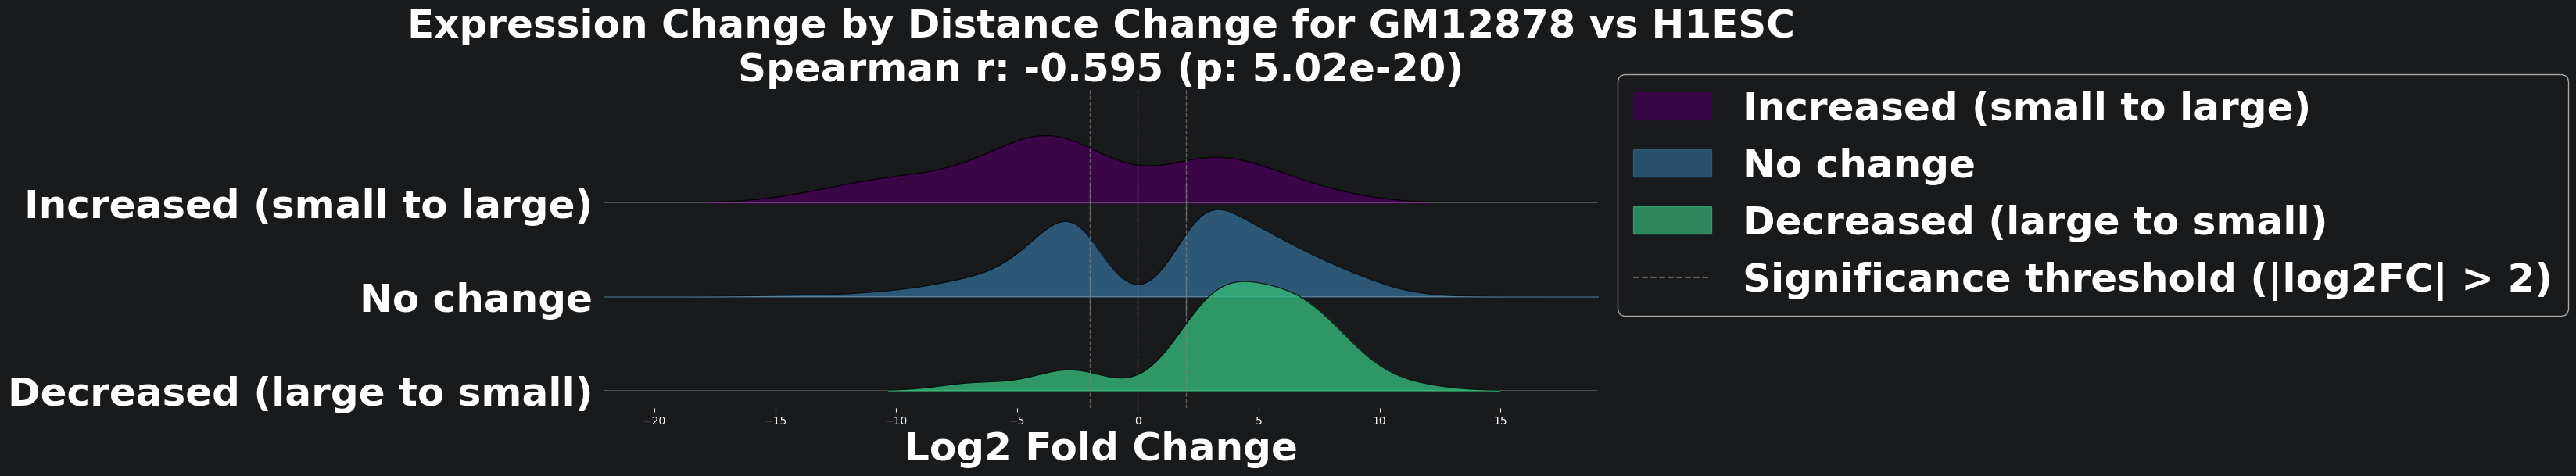

In [44]:
fig, corr_data = plot_distance_vs_expression_correlation(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    figsize=(15, 5),
    plot_path="figs/exp4_gm_h1_joy.png",
    log2fc_threshold=2,
    font_size = 36
)
plt.show()

Pearson r: -0.478, p-value: 1.61e-13
Spearman r: -0.559, p-value: 8.33e-19


/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_4036/4084627900.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(label, fontsize=font_size, fontweight='bold')


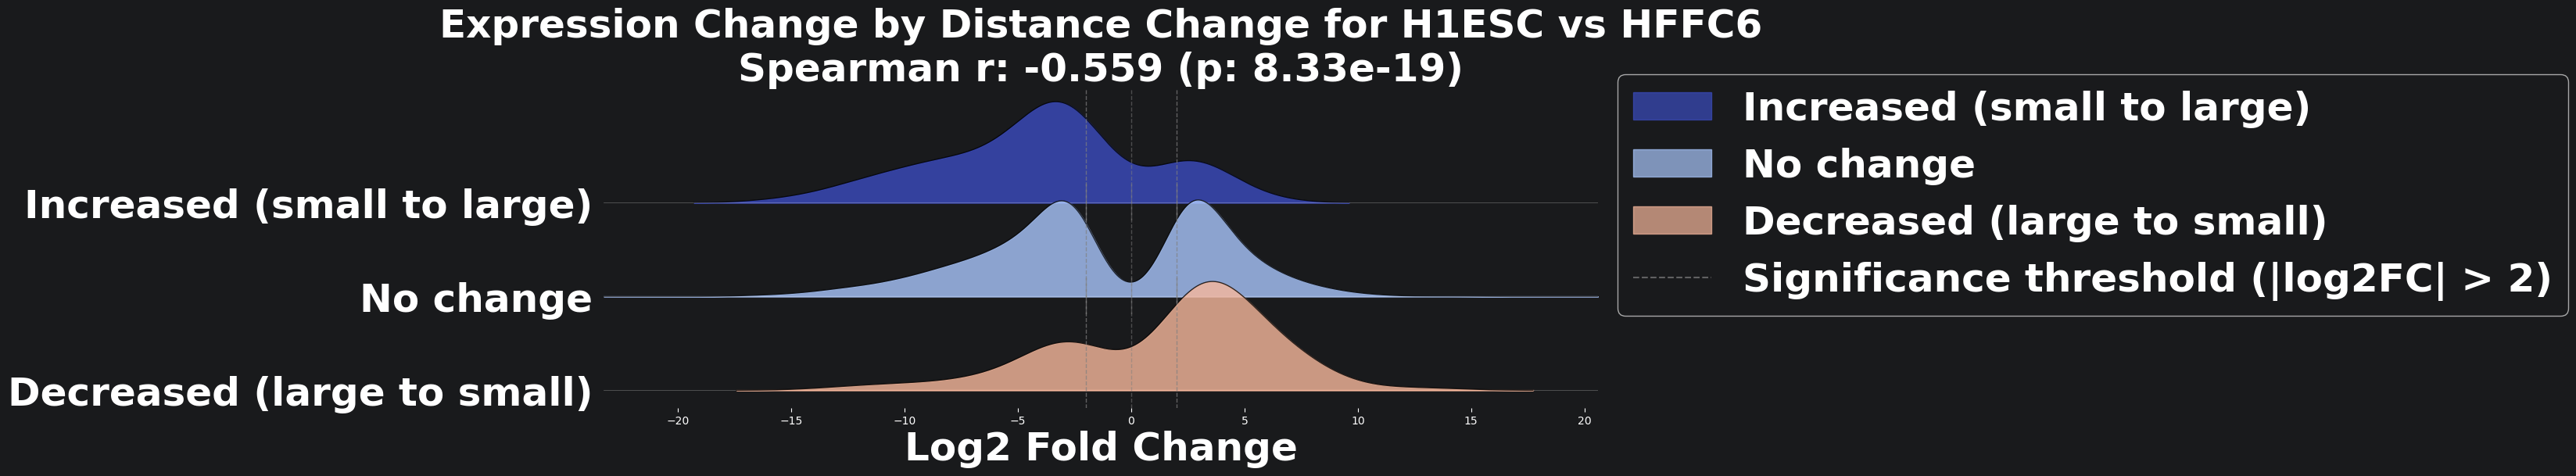

In [45]:
fig, corr_data = plot_distance_vs_expression_correlation(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    figsize=(15, 5),
    plot_path="figs/exp4_h1_hffc_joy.png",
    color_map=cm.coolwarm,
    log2fc_threshold=2,
    font_size = 36
)

plt.show()

Pearson r: -0.561, p-value: 3.24e-16
Spearman r: -0.583, p-value: 1.10e-17


/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_4036/4084627900.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(label, fontsize=font_size, fontweight='bold')


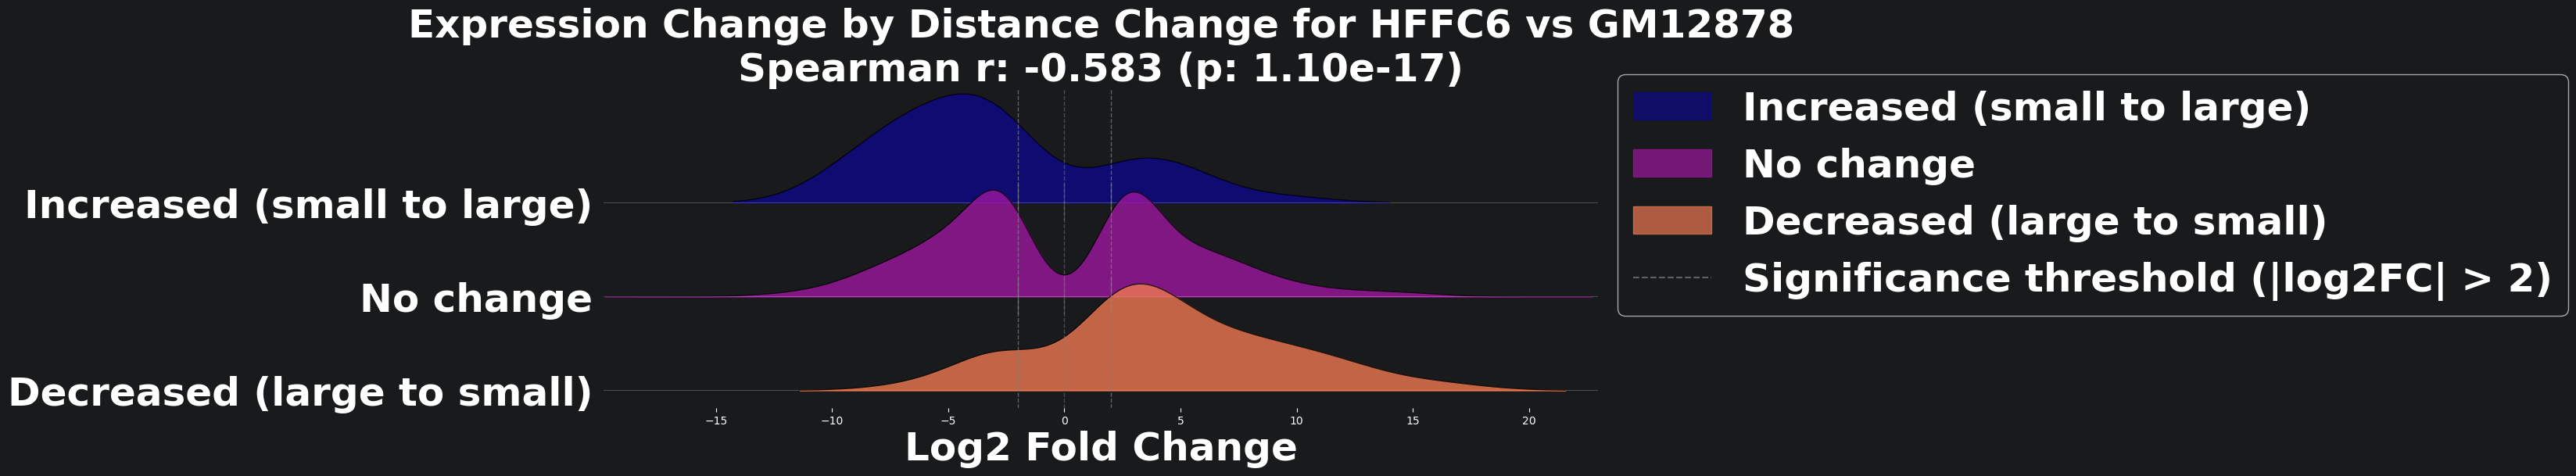

In [46]:
fig, corr_data = plot_distance_vs_expression_correlation(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    figsize=(15, 5),
    plot_path="figs/exp4_hffc_gm_joy.png",
    color_map=cm.plasma,
    log2fc_threshold=2,
    font_size = 36
)

plt.show()

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from gprofiler import GProfiler

gp = GProfiler(
    user_agent='enhancer3d',
    return_dataframe=True,
)

def get_comparison_table_2_cell_lines(
    cell1_distances_df,
    cell2_distances_df,
    deseq_results_df,
    cell1_name,
    cell2_name,
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=True
):
    deseq_results_df = deseq_results_df.copy()
    deseq_results_df.index = deseq_results_df.index.str.split('.').str[0]

    deseq_results_df = deseq_results_df[
        (deseq_results_df["padj"] < padj_threshold)
        & (deseq_results_df["log2FoldChange"].abs() > log2fc_threshold)
    ]

    cell1_distances_df = cell1_distances_df.copy()
    cell1_distances_df['norm_min_dist'] = (
        (cell1_distances_df['min_dist'] - cell1_distances_df['min_dist'].min()) / (cell1_distances_df['min_dist'].max() - cell1_distances_df['min_dist'].min())
    )

    cell2_distances_df = cell2_distances_df.copy()
    cell2_distances_df['norm_min_dist'] = (
        (cell2_distances_df['min_dist'] - cell2_distances_df['min_dist'].min()) / (cell2_distances_df['min_dist'].max() - cell2_distances_df['min_dist'].min())
    )

    combined_df = cell1_distances_df.merge(
        cell2_distances_df,
        left_index=True,
        right_index=True,
        how="inner",
        suffixes=(f"_{cell1_name}", f"_{cell2_name}")
    )

    combined_df["log_dist_ratio"] = np.log2(combined_df[f"min_dist_{cell1_name}"] / combined_df[f"min_dist_{cell2_name}"])
    combined_df["dist_diff"] = combined_df[f"min_dist_{cell1_name}"] - combined_df[f"min_dist_{cell2_name}"]

    combined_df["norm_dist_diff"] = combined_df[f"norm_min_dist_{cell1_name}"] - combined_df[f"norm_min_dist_{cell2_name}"]
    combined_df["log_norm_dist_ratio"] = np.log2(combined_df[f"norm_min_dist_{cell1_name}"] / combined_df[f"norm_min_dist_{cell2_name}"])

    def get_link_change(row):
        if row[f"has_link_{cell1_name}"] and not row[f"has_link_{cell2_name}"]:
            return f"Only {cell1_name}"
        elif not row[f"has_link_{cell1_name}"] and row[f"has_link_{cell2_name}"]:
            return f"Only {cell2_name}"
        elif row[f"has_link_{cell1_name}"] and row[f"has_link_{cell2_name}"]:
            return "Both"
        else:
            return "Neither"

    # combined_df["link_status"] = combined_df.apply(get_link_change, axis=1)

    def get_quartile_change(row):
        q1 = row[f"quartile_cat_{cell1_name}"]
        q2 = row[f"quartile_cat_{cell2_name}"]

        if q1 == q2:
            return "No change"

        categories = ["small", "mid", "large"]
        idx1 = categories.index(q1)
        idx2 = categories.index(q2)

        if idx1 > idx2:
            return f"Decreased ({q1} to {q2})"
        else:
            return f"Increased ({q1} to {q2})"

    combined_df["quartile_change"] = combined_df.apply(get_quartile_change, axis=1)

    merged_df = combined_df.merge(
        deseq_results_df[["log2FoldChange", "padj"]],
        left_index=True,
        right_index=True,
        how="inner"
    )

    # merged_df_for_correlation = merged_df.copy()
    # merged_df_for_correlation = merged_df_for_correlation[
    #     ~merged_df_for_correlation["quartile_change"].isin([
    #         "No change",
    #         "Increased (small to mid)",
    #         "Increased (mid to large)",
    #         "Decreased (large to mid)",
    #         "Decreased (mid to small)",
    #     ])
    # ]

    merged_df_for_genes = merged_df.copy()

    if enable_jump_filtering and enable_expression_filtering:
        cell_line_1_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["log2FoldChange"] < -log2fc_threshold)
            # & (merged_df_for_genes["link_status"] == f"Only {cell1_name}")
            & (merged_df_for_genes["quartile_change"].isin([
                "Increased (small to large)",
                # "Increased (small to mid)",
                "Increased (mid to large)",
            ]))
        ]
    elif enable_jump_filtering:
        cell_line_1_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["quartile_change"].isin([
                "Increased (small to large)",
                # "Increased (small to mid)",
                "Increased (mid to large)",
            ]))
        ]
    elif enable_expression_filtering:
        cell_line_1_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["log2FoldChange"] < -log2fc_threshold)
        ]

    if enable_jump_filtering and enable_expression_filtering:
        cell_line_2_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["log2FoldChange"] > log2fc_threshold)
            # & (merged_df_for_genes["link_status"] == f"Only {cell2_name}")
            & (merged_df_for_genes["quartile_change"].isin([
                "Decreased (large to small)",
                "Decreased (mid to small)",
                # "Decreased (large to mid)",
            ]))
        ]
    elif enable_jump_filtering:
        cell_line_2_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["quartile_change"].isin([
                "Decreased (large to small)",
                "Decreased (mid to small)",
                # "Decreased (large to mid)",
            ]))
        ]
    elif enable_expression_filtering:
         cell_line_2_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["log2FoldChange"] > log2fc_threshold)
        ]


    return cell_line_1_upregulated_jumper_genes, cell_line_2_upregulated_jumper_genes


def get_genes_from_2_cell_lines(
    cell1_distances_df,
    cell2_distances_df,
    deseq_results_df,
    cell1_name,
    cell2_name,
    log2fc_threshold=2,
    padj_threshold=0.05
):
    cell_line_1_upregulated_jumper_genes, cell_line_2_upregulated_jumper_genes = get_comparison_table_2_cell_lines(
        cell1_distances_df,
        cell2_distances_df,
        deseq_results_df,
        cell1_name,
        cell2_name,
        log2fc_threshold,
        padj_threshold,
        True,
        True
    )

    gene_names_cell_line_1 = (
        gp
        .convert(
            organism='hsapiens',
            query=cell_line_1_upregulated_jumper_genes.index.tolist(),
        )
        [['converted', 'name']]
        .set_index('converted', drop=True)
    )

    gene_names_cell_line_2 = (
        gp
        .convert(
            organism='hsapiens',
            query=cell_line_2_upregulated_jumper_genes.index.tolist(),
        )
        [['converted', 'name']]
        .set_index('converted', drop=True)
    )

    return list(filter(None, gene_names_cell_line_1['name'].tolist())), list(filter(None, gene_names_cell_line_2['name'].tolist()))

In [48]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from textwrap import wrap
import gseapy

def get_enrichment_results(gene_list, gene_sets):
    enr = gseapy.enrichr(
        gene_list=gene_list,
        gene_sets=gene_sets,
        organism='Human',
        outdir=None,
        cutoff=0.05
    )

    results = enr.results[['Term', 'P-value', 'Adjusted P-value', 'Overlap', 'Combined Score', 'Genes']]
    results['Genes Ratio'] = results['Genes'].apply(lambda x: len(x.split(';')) / len(gene_list))
    results['Genes Number'] = results['Genes'].apply(lambda x: len(x.split(';')))
    return results.reset_index(drop=True)

def dotplot(
    results,
    figsize=(8, 8),
    fontsize=24,
    title="Enrichment Results",
    xlabel="Combined Score",
    ylabel="Term",
    plot_path=None,
    palette=sns.mpl_palette("spring", as_cmap=True)
):
    # results = results[results['Adjusted P-value'] <= 0.05]
    results = results.sort_values(by='Combined Score', ascending=False).head(10)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=results,
        x='Combined Score',
        y='Term',
        hue='Adjusted P-value',
        hue_norm=(0, 1),
        palette=palette,
        ax=ax,
        legend=False,
    )

    norm = Normalize(vmin=0, vmax=1)
    sm = ScalarMappable(cmap=palette, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Adjusted P-value', shrink=0.8)
    cbar.ax.tick_params(labelsize=fontsize-2)
    cbar.set_label('Adjusted P-value', fontsize=fontsize, labelpad=10)

    # handles, labels = ax.get_legend_handles_labels()
    # size_legend = ax.legend(
    #     handles=handles[:len(handles)//2],
    #     labels=labels[:len(labels)//2],
    #     title='Combined Score',
    #     bbox_to_anchor=(1.05, 1),
    #     loc='upper left',
    #     fontsize=fontsize-2,
    #     title_fontsize=fontsize
    # )


    ax.set_title(title, fontsize=fontsize)
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)

    ax.tick_params(axis='y', which='major', labelsize=fontsize // 1.5)
    # force y-axis labels to be wrapped
    ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=fontsize // 2)

    ax.tick_params(axis='x', which='major', labelsize=fontsize // 1.5)

    plt.tight_layout()
    if plot_path:
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    return fig

In [49]:
gm12878_genes_1, h1esc_genes_1 = get_genes_from_2_cell_lines(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    log2fc_threshold=2,
    padj_threshold=0.05
)

In [50]:
h1esc_genes_2, hffc6_genes_1 = get_genes_from_2_cell_lines(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    log2fc_threshold=2,
    padj_threshold=0.05
)

/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [51]:
hffc6_genes_2, gm12878_genes_2 = get_genes_from_2_cell_lines(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    log2fc_threshold=2,
    padj_threshold=0.05
)

In [52]:
gm12878_genes = gm12878_genes_1 + gm12878_genes_2
h1esc_genes = h1esc_genes_1 + h1esc_genes_2
hffc6_genes = hffc6_genes_1 + hffc6_genes_2

In [53]:
# dotplot(get_enrichment_results(h1esc_genes, gene_sets='GO_Biological_Process_2025'), title="H1ESC - GO Biological Process",
#         plot_path="figs/exp4_h1esc_enrichment_go.png")
# dotplot(get_enrichment_results(h1esc_genes, gene_sets='Reactome_Pathways_2024'), title="H1ESC - Reactome Pathways",
#         plot_path="figs/exp4_h1esc_enrichment_reactome.png")
# dotplot(get_enrichment_results(h1esc_genes, gene_sets='CellMarker_2024'), title="H1ESC - CellMarker",
#         plot_path="figs/exp4_h1esc_enrichment_cellmarker.png")
# print("H1ESC upregulated jumper genes:")
# print("\n".join(h1esc_genes))

In [54]:
# dotplot(get_enrichment_results(hffc6_genes, gene_sets='GO_Biological_Process_2025'), title="HFFC6 - GO Biological Process",
#         plot_path="figs/exp4_hffc6_enrichment_go.png")
# dotplot(get_enrichment_results(hffc6_genes, gene_sets='Reactome_Pathways_2024'), title="HFFC6 - Reactome Pathways",
#         plot_path="figs/exp4_hffc6_enrichment_reactome.png")
# dotplot(get_enrichment_results(hffc6_genes, gene_sets='CellMarker_2024'), title="HFFC6 - CellMarker",
#         plot_path="figs/exp4_hffc6_enrichment_cellmarker.png")
# print("HFFC6 upregulated jumper genes:")
# print("\n".join(hffc6_genes))

In [55]:
# dotplot(get_enrichment_results(gm12878_genes, gene_sets='GO_Biological_Process_2025'), title="GM12878 - GO Biological Process", plot_path="figs/exp4_gm12878_enrichment_go.png")
# dotplot(get_enrichment_results(gm12878_genes, gene_sets='Reactome_Pathways_2024'), title="GM12878 - Reactome Pathways", plot_path="figs/exp4_gm12878_enrichment_reactome.png")
# dotplot(get_enrichment_results(gm12878_genes, gene_sets='CellMarker_2024'), title="GM12878 - CellMarker", plot_path="figs/exp4_gm12878_enrichment_cellmarker.png")
# print("GM12878 upregulated jumper genes:")
# print("\n".join(gm12878_genes))

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from textwrap import wrap
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def dotplot2(
    results,
    cell_order=('HFFC6', 'H1ESC', 'GM12878'),
    figsize=(8, 12),
    fontsize=20,
    title="Top enriched pathways\n(size ~ enrichment score)",
    xlabel="Cell type",
    ylabel="",
    marker_color="#D39A1A",   # gold-like color used in example image
    adj_pvalue_sign_marker_color="#D21F3C", # for
    min_marker=160,
    max_marker=2200,
    plot_path=None,
    max_adj_pvalue=0.2
):
    """
    results: DataFrame with columns: 'Term', 'CellType', 'Combined Score', 'Adjusted P-value' (optional)
    cell_order: tuple/list with the three cell types in the desired left->right order
    """
    results = results[results['Adjusted P-value'] <= max_adj_pvalue]
    results = (
        results
        .sort_values(by=['Adjusted P-value'], ascending=True)
        .groupby('CellType', group_keys=False)
        .head(10)
    )
    results = results.sort_values(by=['CellType', 'Combined Score'], ascending=False)


    # Validate presence of columns
    required = {'Term', 'CellType', 'Combined Score'}
    missing = required - set(results.columns)
    if missing:
        raise ValueError(f"results is missing required columns: {missing}")

    # order of y-terms (preserve order if present, otherwise take unique)
    terms = list(results['Term'].unique())
    n_terms = len(terms)
    y_positions = np.arange(n_terms)[::-1]   # top-to-bottom

    # mapping term -> y index
    term_to_y = {term: y for term, y in zip(terms, y_positions)}

    # mapping cell -> x position
    x_positions = np.arange(len(cell_order))
    cell_to_x = {cell: x for cell, x in zip(cell_order, x_positions)}

    # sizes: scale Combined Score to sensible marker sizes
    cs_values = results['Combined Score'].astype(float)
    cs_min, cs_max = cs_values.min(), cs_values.max()
    denom = cs_max - cs_min if cs_max != cs_min else 1.0

    def scale_size(cs):
        return ((cs - cs_min) / denom) * (max_marker - min_marker) + min_marker

    fig, ax = plt.subplots(figsize=figsize)

    # horizontal dotted guide lines
    for y in y_positions:
        ax.hlines(y, xmin=-0.5, xmax=len(cell_order)-0.5, colors='lightgray', linestyles='dotted', linewidth=1)

    # vertical dashed separators (draw at each cell x)
    for x in x_positions:
        ax.axvline(x=x, color='lightgray', linestyle='dashed', linewidth=1, zorder=0)

    # Plot each row as a single 'X' marker at (cell_x, term_y)
    for _, row in results.iterrows():
        term = row['Term']
        cell = row['CellType']
        if term not in term_to_y or cell not in cell_to_x:
            # skip unexpected entries
            continue
        x = cell_to_x[cell]
        y = term_to_y[term]
        s = scale_size(float(row['Combined Score']))
        # alpha can reflect Adjusted P-value if present (smaller p -> stronger -> higher alpha)
        alpha = 1.0
        color = marker_color
        if 'Adjusted P-value' in results.columns:
            adj = float(row['Adjusted P-value'])
            alpha = max(0.25, 1 - adj)
            color = adj_pvalue_sign_marker_color if adj <= 0.05 else marker_color

        ax.scatter([x], [y], s=s, marker='X', color=color, linewidths=2.5, edgecolors='black', alpha=alpha, zorder=3)

    # axis formatting
    ax.set_xlim(-0.6, len(cell_order)-0.4)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(cell_order, fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=fontsize+2, labelpad=12, fontweight='bold')

    # y-axis labels: wrap and place at left
    wrapped = ['\n'.join(wrap(t, width=30)) for t in terms]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(wrapped, fontsize=fontsize // 2, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=fontsize, fontweight='bold')

    # Title
    ax.set_title(title, fontsize=fontsize+4, pad=20, fontweight='bold')

    # Remove top/right spines, keep left spine for axis line similar to picture
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_visible(False)

    # x tick baseline thick line (mimics bold baseline in example)
    ax.axhline(y=y_positions.min()-1.2, color='black', linewidth=3.0, zorder=2)

    # tidy up
    ax.invert_yaxis()  # so first term appears at top
    plt.tight_layout()

    if plot_path:
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')

    return fig, ax


In [57]:
h1esc_reactomes = get_enrichment_results(h1esc_genes, gene_sets='Reactome_Pathways_2024')
hffc6_reactomes = get_enrichment_results(hffc6_genes, gene_sets='Reactome_Pathways_2024')
gm12878_reactomes = get_enrichment_results(gm12878_genes, gene_sets='Reactome_Pathways_2024')

h1esc_reactomes['CellType'] = 'H1ESC'
hffc6_reactomes['CellType'] = 'HFFC6'
gm12878_reactomes['CellType'] = 'GM12878'

/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_4036/2898919781.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Genes Ratio'] = results['Genes'].apply(lambda x: len(x.split(';')) / len(gene_list))
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_4036/2898919781.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Genes Number'] = results['Genes'].apply(lambda x: len(x.split(';')))
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_4036/2898919781.py:17: Se

In [58]:
gm12878_reactomes.to_csv("export/gm12878_reactomes.csv")
hffc6_reactomes.to_csv("export/hffc6_reactomes.csv")
h1esc_reactomes.to_csv("export/h1esc_reactomes.csv")

(<Figure size 800x1200 with 1 Axes>,
 <Axes: title={'center': 'Top enriched pathways\n(size ~ enrichment score)'}, xlabel='Cell type'>)

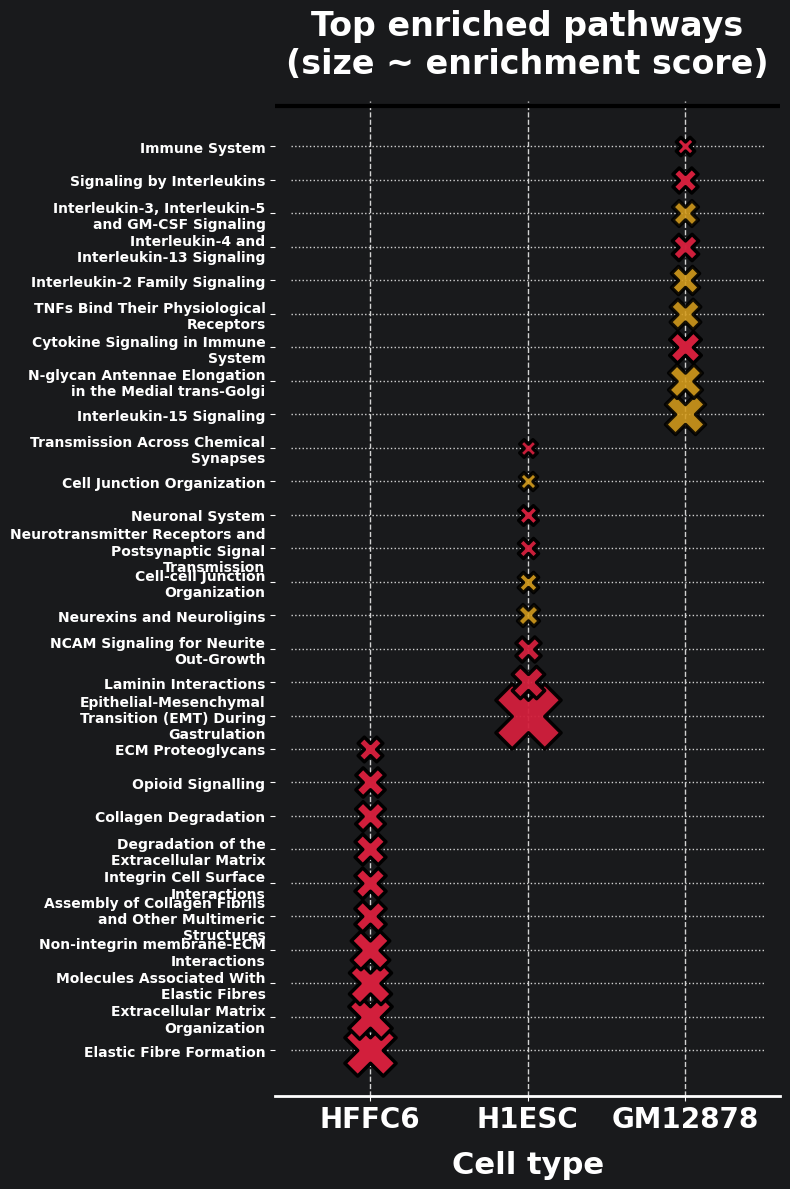

In [59]:
dotplot2(pd.concat([gm12878_reactomes, hffc6_reactomes, h1esc_reactomes]), fontsize=20, plot_path="figs/exp4_full_enrichment_reactomes.png")

In [60]:
print("H1ESC")
for term in h1esc_reactomes['Term']:
    print(term)

print("GM12877")
for term in gm12878_reactomes['Term']:
    print(term)

print("HFFC6")
for term in hffc6_reactomes['Term']:
    print(term)

H1ESC
Neuronal System
Neurotransmitter Receptors and Postsynaptic Signal Transmission
Transmission Across Chemical Synapses
Epithelial-Mesenchymal Transition (EMT) During Gastrulation
NCAM Signaling for Neurite Out-Growth
Laminin Interactions
Cell-cell Junction Organization
Cell Junction Organization
Neurexins and Neuroligins
Repression of WNT Target Genes
Nervous System Development
SUMOylation of DNA Methylation Proteins
IRS Activation
Axon Guidance
Trafficking of GluR2-containing AMPA Receptors
Insulin Receptor Signalling Cascade
Cell-Cell Communication
VLDL Clearance
Non-integrin membrane-ECM Interactions
Ras Activation Upon Ca2+ Influx Through NMDA Receptor
GABA Receptor Activation
RHO GTPases Activate PAKs
Protein-protein Interactions at Synapses
Extracellular Matrix Organization
SHC1 Events in ERBB2 Signaling
Activation of GABAB Receptors
GABA B Receptor Activation
Vasopressin Regulates Renal Water Homeostasis via Aquaporins
EPH-Ephrin Signaling
Activation of NMDA Receptors and P

In [61]:
gm12878_vs_h1esc_downregulated_jumps_only, gm12878_vs_h1esc_upregulated_jumps_only = get_comparison_table_2_cell_lines(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=False
)

gm12878_vs_h1esc_downregulated_expression_only, gm12878_vs_h1esc_upregulated_expression_only = get_comparison_table_2_cell_lines(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=False,
    enable_expression_filtering=True
)

gm12878_vs_h1esc_downregulated_jumps_expression_both, gm12878_vs_h1esc_upregulated_jumps_expression_both = get_comparison_table_2_cell_lines(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=True
)

gm12878_vs_h1esc_downregulated_jumps_only = gm12878_vs_h1esc_downregulated_jumps_only[['min_dist_GM12878', 'min_dist_H1ESC', 'quartile_cat_GM12878', 'quartile_cat_H1ESC']]
gm12878_vs_h1esc_downregulated_jumps_only.to_csv("export/gm12878_vs_h1esc_downregulated_jumps_only.csv")
print('gm12878_vs_h1esc_downregulated_jumps_only', len(gm12878_vs_h1esc_downregulated_jumps_only))

gm12878_vs_h1esc_upregulated_jumps_only = gm12878_vs_h1esc_upregulated_jumps_only[['min_dist_GM12878', 'min_dist_H1ESC', 'quartile_cat_GM12878', 'quartile_cat_H1ESC']]
gm12878_vs_h1esc_upregulated_jumps_only.to_csv("export/gm12878_vs_h1esc_upregulated_jumps_only.csv")
print('gm12878_vs_h1esc_upregulated_jumps_only', len(gm12878_vs_h1esc_upregulated_jumps_only))

gm12878_vs_h1esc_downregulated_expression_only = gm12878_vs_h1esc_downregulated_expression_only[['log2FoldChange', 'padj']]
gm12878_vs_h1esc_downregulated_expression_only.to_csv("export/gm12878_vs_h1esc_downregulated_expression_only.csv")
print('gm12878_vs_h1esc_downregulated_expression_only', len(gm12878_vs_h1esc_downregulated_expression_only))

gm12878_vs_h1esc_upregulated_expression_only = gm12878_vs_h1esc_upregulated_expression_only[['log2FoldChange', 'padj']]
gm12878_vs_h1esc_upregulated_expression_only.to_csv("export/gm12878_vs_h1esc_upregulated_expression_only.csv")
print('gm12878_vs_h1esc_upregulated_expression_only', len(gm12878_vs_h1esc_upregulated_expression_only))

gm12878_vs_h1esc_downregulated_jumps_expression_both = gm12878_vs_h1esc_downregulated_jumps_expression_both[['min_dist_GM12878', 'min_dist_H1ESC', 'quartile_cat_GM12878', 'quartile_cat_H1ESC', 'log2FoldChange', 'padj']]
gm12878_vs_h1esc_downregulated_jumps_expression_both.to_csv("export/gm12878_vs_h1esc_downregulated_jumps_expression_both.csv")
print('gm12878_vs_h1esc_downregulated_jumps_expression_both', len(gm12878_vs_h1esc_downregulated_jumps_expression_both))

gm12878_vs_h1esc_upregulated_jumps_expression_both = gm12878_vs_h1esc_upregulated_jumps_expression_both[['min_dist_GM12878', 'min_dist_H1ESC', 'quartile_cat_GM12878', 'quartile_cat_H1ESC', 'log2FoldChange', 'padj']]
gm12878_vs_h1esc_upregulated_jumps_expression_both.to_csv("export/gm12878_vs_h1esc_upregulated_jumps_expression_both.csv")
print('gm12878_vs_h1esc_upregulated_jumps_expression_both', len(gm12878_vs_h1esc_upregulated_jumps_expression_both))

gm12878_vs_h1esc_downregulated_jumps_only 192
gm12878_vs_h1esc_upregulated_jumps_only 421
gm12878_vs_h1esc_downregulated_expression_only 1193
gm12878_vs_h1esc_upregulated_expression_only 1573
gm12878_vs_h1esc_downregulated_jumps_expression_both 128
gm12878_vs_h1esc_upregulated_jumps_expression_both 297


In [62]:
h1esc_vs_hffc6_downregulated_jumps_only, h1esc_vs_hffc6_upregulated_jumps_only = get_comparison_table_2_cell_lines(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=False
)

h1esc_vs_hffc6_downregulated_expression_only, h1esc_vs_hffc6_upregulated_expression_only = get_comparison_table_2_cell_lines(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=False,
    enable_expression_filtering=True
)

h1esc_vs_hffc6_downregulated_jumps_expression_both, h1esc_vs_hffc6_upregulated_jumps_expression_both = get_comparison_table_2_cell_lines(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=True
)

h1esc_vs_hffc6_downregulated_jumps_only = h1esc_vs_hffc6_downregulated_jumps_only[
    ['min_dist_H1ESC', 'min_dist_HFFC6', 'quartile_cat_H1ESC', 'quartile_cat_HFFC6']
]
h1esc_vs_hffc6_downregulated_jumps_only.to_csv("export/h1esc_vs_hffc6_downregulated_jumps_only.csv")
print('h1esc_vs_hffc6_downregulated_jumps_only', len(h1esc_vs_hffc6_downregulated_jumps_only))

h1esc_vs_hffc6_upregulated_jumps_only = h1esc_vs_hffc6_upregulated_jumps_only[
    ['min_dist_H1ESC', 'min_dist_HFFC6', 'quartile_cat_H1ESC', 'quartile_cat_HFFC6']
]
h1esc_vs_hffc6_upregulated_jumps_only.to_csv("export/h1esc_vs_hffc6_upregulated_jumps_only.csv")
print('h1esc_vs_hffc6_upregulated_jumps_only', len(h1esc_vs_hffc6_upregulated_jumps_only))

h1esc_vs_hffc6_downregulated_expression_only = h1esc_vs_hffc6_downregulated_expression_only[
    ['log2FoldChange', 'padj']
]
h1esc_vs_hffc6_downregulated_expression_only.to_csv("export/h1esc_vs_hffc6_downregulated_expression_only.csv")
print('h1esc_vs_hffc6_downregulated_expression_only', len(h1esc_vs_hffc6_downregulated_expression_only))

h1esc_vs_hffc6_upregulated_expression_only = h1esc_vs_hffc6_upregulated_expression_only[
    ['log2FoldChange', 'padj']
]
h1esc_vs_hffc6_upregulated_expression_only.to_csv("export/h1esc_vs_hffc6_upregulated_expression_only.csv")
print('h1esc_vs_hffc6_upregulated_expression_only', len(h1esc_vs_hffc6_upregulated_expression_only))

h1esc_vs_hffc6_downregulated_jumps_expression_both = h1esc_vs_hffc6_downregulated_jumps_expression_both[
    ['min_dist_H1ESC', 'min_dist_HFFC6',
     'quartile_cat_H1ESC', 'quartile_cat_HFFC6',
     'log2FoldChange', 'padj']
]
h1esc_vs_hffc6_downregulated_jumps_expression_both.to_csv("export/h1esc_vs_hffc6_downregulated_jumps_expression_both.csv")
print('h1esc_vs_hffc6_downregulated_jumps_expression_both', len(h1esc_vs_hffc6_downregulated_jumps_expression_both))

h1esc_vs_hffc6_upregulated_jumps_expression_both = h1esc_vs_hffc6_upregulated_jumps_expression_both[
    ['min_dist_H1ESC', 'min_dist_HFFC6',
     'quartile_cat_H1ESC', 'quartile_cat_HFFC6',
     'log2FoldChange', 'padj']
]
h1esc_vs_hffc6_upregulated_jumps_expression_both.to_csv("export/h1esc_vs_hffc6_upregulated_jumps_expression_both.csv")
print('h1esc_vs_hffc6_upregulated_jumps_expression_both', len(h1esc_vs_hffc6_upregulated_jumps_expression_both))

/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


h1esc_vs_hffc6_downregulated_jumps_only 227
h1esc_vs_hffc6_upregulated_jumps_only 453
h1esc_vs_hffc6_downregulated_expression_only 1825
h1esc_vs_hffc6_upregulated_expression_only 1380
h1esc_vs_hffc6_downregulated_jumps_expression_both 177
h1esc_vs_hffc6_upregulated_jumps_expression_both 274


In [63]:
hffc6_vs_gm12878_downregulated_jumps_only, hffc6_vs_gm12878_upregulated_jumps_only = get_comparison_table_2_cell_lines(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=False
)

hffc6_vs_gm12878_downregulated_expression_only, hffc6_vs_gm12878_upregulated_expression_only = get_comparison_table_2_cell_lines(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=False,
    enable_expression_filtering=True
)

hffc6_vs_gm12878_downregulated_jumps_expression_both, hffc6_vs_gm12878_upregulated_jumps_expression_both = get_comparison_table_2_cell_lines(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    log2fc_threshold=0,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=True
)

hffc6_vs_gm12878_downregulated_jumps_only = hffc6_vs_gm12878_downregulated_jumps_only[
    ['min_dist_HFFC6', 'min_dist_GM12878', 'quartile_cat_HFFC6', 'quartile_cat_GM12878']
]
hffc6_vs_gm12878_downregulated_jumps_only.to_csv("export/hffc6_vs_gm12878_downregulated_jumps_only.csv")
print('hffc6_vs_gm12878_downregulated_jumps_only', len(hffc6_vs_gm12878_downregulated_jumps_only))

hffc6_vs_gm12878_upregulated_jumps_only = hffc6_vs_gm12878_upregulated_jumps_only[
    ['min_dist_HFFC6', 'min_dist_GM12878', 'quartile_cat_HFFC6', 'quartile_cat_GM12878']
]
hffc6_vs_gm12878_upregulated_jumps_only.to_csv("export/hffc6_vs_gm12878_upregulated_jumps_only.csv")
print('hffc6_vs_gm12878_upregulated_jumps_only', len(hffc6_vs_gm12878_upregulated_jumps_only))

hffc6_vs_gm12878_downregulated_expression_only = hffc6_vs_gm12878_downregulated_expression_only[
    ['log2FoldChange', 'padj']
]
hffc6_vs_gm12878_downregulated_expression_only.to_csv("export/hffc6_vs_gm12878_downregulated_expression_only.csv")
print('hffc6_vs_gm12878_downregulated_expression_only', len(hffc6_vs_gm12878_downregulated_expression_only))

hffc6_vs_gm12878_upregulated_expression_only = hffc6_vs_gm12878_upregulated_expression_only[
    ['log2FoldChange', 'padj']
]
hffc6_vs_gm12878_upregulated_expression_only.to_csv("export/hffc6_vs_gm12878_upregulated_expression_only.csv")
print('hffc6_vs_gm12878_upregulated_expression_only', len(hffc6_vs_gm12878_upregulated_expression_only))

hffc6_vs_gm12878_downregulated_jumps_expression_both = hffc6_vs_gm12878_downregulated_jumps_expression_both[
    ['min_dist_HFFC6', 'min_dist_GM12878',
     'quartile_cat_HFFC6', 'quartile_cat_GM12878',
     'log2FoldChange', 'padj']
]
hffc6_vs_gm12878_downregulated_jumps_expression_both.to_csv("export/hffc6_vs_gm12878_downregulated_jumps_expression_both.csv")
print('hffc6_vs_gm12878_downregulated_jumps_expression_both', len(hffc6_vs_gm12878_downregulated_jumps_expression_both))

hffc6_vs_gm12878_upregulated_jumps_expression_both = hffc6_vs_gm12878_upregulated_jumps_expression_both[
    ['min_dist_HFFC6', 'min_dist_GM12878',
     'quartile_cat_HFFC6', 'quartile_cat_GM12878',
     'log2FoldChange', 'padj']
]
hffc6_vs_gm12878_upregulated_jumps_expression_both.to_csv("export/hffc6_vs_gm12878_upregulated_jumps_expression_both.csv")
print('hffc6_vs_gm12878_upregulated_jumps_expression_both', len(hffc6_vs_gm12878_upregulated_jumps_expression_both))

hffc6_vs_gm12878_downregulated_jumps_only 272
hffc6_vs_gm12878_upregulated_jumps_only 345
hffc6_vs_gm12878_downregulated_expression_only 1349
hffc6_vs_gm12878_upregulated_expression_only 1377
hffc6_vs_gm12878_downregulated_jumps_expression_both 406
hffc6_vs_gm12878_upregulated_jumps_expression_both 802
